# Yelp Reviews: Text Features vs Star Ratings

**Goal:** To examine how interpretable text-derived features from Yelp reviews relate to numeric star ratings, focusing on agreement and mismatch rather than prediction or automated classification.
Rather than building a predictive model, this analysis explores whether simple, transparent signals extracted from review text convey information that is consistent with, or diverges from, the associated star ratings.

**Research questions**
- **RQ1:** How frequently do star ratings and text-derived sentiment signals disagree within Yelp reviews?
- **RQ2:** Which observable text characteristics (e.g. length, sentiment polarity, use of questions) are associated with larger rating–text mismatches?
- **RQ3:** Is disagreement symmetric, or do certain types of mismatch (e.g. positive text with low star ratings versus negative text with high star ratings) occur more often?

## 1. Set up and Path organization

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Text: VADER sentiment (fast lexicon-based)
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon", quiet=True)


True

In [2]:
# Paths
root = Path.cwd()

data_dir = root / "data" / "yelp"
review_path = data_dir / "yelp_academic_dataset_review.json"
business_path = data_dir / "yelp_academic_dataset_business.json"

assert review_path.exists(), f"Missing: {review_path}"
assert business_path.exists(), f"Missing: {business_path}"

## 2. Data Loading and Wrangling

### JSON file loading function

This function loads a large .json file incrementally using chunks to avoid memory issues when working with large Yelp datasets. Only the required columns are kept, and basic validation ensures the expected schema is present.

Lightweight data cleaning is applied during loading, missing text and star ratings are removed, text is coerced to strings, numeric fields are cast to memory efficient types, and dates are parsed safely. Count variables (useful, funny, cool) are standardised by filling missing values with zero.

A maximum row limit is enforced to obtain a manageable but representative subset for analysis. The cleaned chunks are then concatenated into a single dataframe ready for downstream exploration.

In [3]:
# Function to load JSON in chunks with cleaning
def load_json(path, usecols, max_rows, chunksize):
    path = Path(path)
    out = []
    total = 0

    for chunk in pd.read_json(path, lines=True, chunksize=chunksize):
        missing = [c for c in usecols if c not in chunk.columns]
        if missing:
            raise KeyError(f"Missing columns: {missing}. Available: {list(chunk.columns)}")

        chunk = chunk[usecols].copy()

        # Drop rows with missing essentials
        if "text" in chunk.columns:
            chunk = chunk.dropna(subset=["text"])
            chunk["text"] = chunk["text"].astype(str)
        if "stars" in chunk.columns:
            chunk = chunk.dropna(subset=["stars"])
            chunk["stars"] = chunk["stars"].astype("float32")

        # Cast counts if present
        for c in ["useful", "funny", "cool"]:
            if c in chunk.columns:
                chunk[c] = chunk[c].fillna(0).astype("int16")

        if "date" in chunk.columns:
            chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")

        # Enforce max_rows
        remaining = max_rows - total
        if remaining <= 0:
            break
        if len(chunk) > remaining:
            chunk = chunk.iloc[:remaining].copy()

        out.append(chunk)
        total += len(chunk)

        print(f"Kept {len(chunk):,} rows, total {total:,}")

        if total >= max_rows:
            break

    if out:
        return pd.concat(out, ignore_index=True)
    else:
        return pd.DataFrame(columns=usecols)


In [4]:
# Load reviews + business
review_cols = ["review_id", "business_id", "stars", "text", "useful", "funny", "cool", "date"]
business_cols = ["business_id", "name", "city", "state", "stars", "review_count", "categories"]

reviews = load_json(review_path, usecols=review_cols, max_rows=500_000, chunksize=100_000)
business = load_json(business_path, usecols=business_cols, max_rows=100_000, chunksize=50_000)

reviews.shape, business.shape

Kept 100,000 rows, total 100,000
Kept 100,000 rows, total 200,000
Kept 100,000 rows, total 300,000
Kept 100,000 rows, total 400,000
Kept 100,000 rows, total 500,000
Kept 50,000 rows, total 50,000
Kept 50,000 rows, total 100,000


((500000, 8), (100000, 7))

In [5]:
# Merge business info
df = reviews.merge(
    business.rename(columns={"stars": "business_stars"}),
    on="business_id",
    how="left"
)

df.shape
df["name"].isna().mean()

0.0

A subset of the Yelp dataset was used to balance computational feasibility with analytical coverage. In total, 500,000 reviews and 100,000 businesses were selected for analysis.

The following columns were retained from 
- the review data: [review_id, business_id, stars, text, useful, funny, cool, date]
- the business data: [business_id, name, city, state, stars, review_count, categories]

The review and business datasets were merged using a left join on business_id, ensuring that all review records were retained even when corresponding business information was missing.

Preprocessing steps included removing records with missing review text or star ratings, standardising data types, and parsing date fields into a datetime format. The result is a single, cleaned dataset suitable for exploratory analysis and feature construction.

## 3. Initial check and Basic Inspection

In [6]:
# Quick look at reviews
display(reviews.head(3))
print(reviews.dtypes)
print("\nStars counts:\n", reviews["stars"].value_counts(dropna=False).sort_index())
print("\nUsefulness summary:\n", reviews["useful"].describe())

,review_id,business_id,stars,text,useful,funny,cool,date
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"If you decide to eat here, just be aware it is...",0,0,0,2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,7ATYjTIgM3jUlt4UM3IypQ,5.0,I've taken a lot of spin classes over the year...,1,0,1,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,3.0,Family diner. Had the buffet. Eclectic assortm...,0,0,0,2014-02-05 20:30:30


review_id              object
business_id            object
stars                 float32
text                   object
useful                  int16
funny                   int16
cool                    int16
date           datetime64[ns]
dtype: object

Stars counts:
 stars
1.0     65233
2.0     38856
3.0     52589
4.0    114005
5.0    229317
Name: count, dtype: int64

Usefulness summary:
 count    500000.000000
mean          1.028570
std           2.409103
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         320.000000
Name: useful, dtype: float64


## 4. Exploratory distribution

### Star Rating Distribution

A star rating distribution is plotted to familiarise myself with the basic structure of the dataset and to illustrate how reviews are distributed across ratings before moving into more detailed feature engineering and comparative analysis.

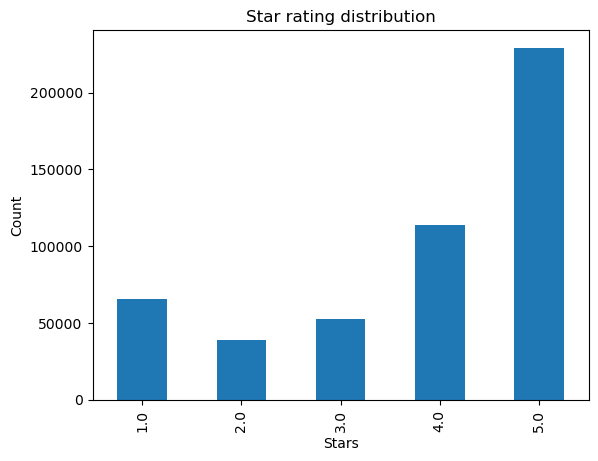

In [7]:
plt.figure()
df["stars"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.title("Star rating distribution")
plt.show()

- The distribution is strongly left skewed, with 5-star reviews dominating by a large margin.  
    -  4-star reviews are the next most common, while 1–3 stars are comparatively rare, especially 2-star ratings.
- This suggests a positivity bias typical of review platforms: users are more likely to leave reviews when experiences are very good rather than average or slightly negative.
- Analytically, this class imbalance matters: simple averages may be misleading, and disagreement analyses (text vs stars) should account for the fact that high-star reviews are the majority baseline.

## 5. Text processing & feature construction

In [8]:
def basic_text_normalise(s):
    s = s.replace("\r", " ").replace("\n", " ")
    s = " ".join(s.split())
    return s

sia = SentimentIntensityAnalyzer()

def vader_compound(s: str) -> float:
    return float(sia.polarity_scores(s)["compound"])

### VADER

VADER was chosen because it is well suited to short, opinionated user-generated text such as online reviews, and is designed to handle features like negation, intensifiers, punctuation, and contrastive phrasing that are important when sentiment and star ratings may diverge. In addition, its rule- and lexicon-based design makes it transparent and interpretable, allowing sentiment scores to be clearly explained and linked to engineered text features, which fits an exploratory and explanatory analysis without relying on black-box models.

In [ ]:
# Feature engineering (interpretable text-derived features)
df = df.copy()
df["text_norm"] = df["text"].map(basic_text_normalise)

# Text-based features
df["n_chars"] = df["text_norm"].str.len().astype("int32")
df["n_words"] = df["text_norm"].str.split().str.len().astype("int32")
df["n_exclaim"] = df["text_norm"].map(lambda s: s.count("!")).astype("int16")
df["n_question"] = df["text_norm"].map(lambda s: s.count("?")).astype("int16")
df["n_caps_words"] = df["text_norm"].map(lambda s: sum(1 for w in s.split() if w.isupper() and len(w) >= 2)).astype("int16")
df["caps_ratio"] = (df["n_caps_words"] / df["n_words"].clip(lower=1)).astype("float32")

# Lexicon-based sentiment
df["sent_compound"] = df["text_norm"].map(vader_compound).astype("float32")

# Coarse sentiment labels (for interpretation)
df["sent_label"] = pd.cut(                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
    df["sent_compound"],
    bins=[-1.0, -0.05, 0.05, 1.0],
    labels=["negative", "neutral", "positive"],
    include_lowest=True
)

df[["stars", "sent_compound", "sent_label", "n_words", "n_exclaim", "n_question", "caps_ratio"]].head()

,stars,sent_compound,sent_label,n_words,n_exclaim,n_question,caps_ratio
0,3.0,0.8597,positive,101,1,0,0.009901
1,5.0,0.9858,positive,151,1,0,0.000000
2,3.0,0.9201,positive,55,0,0,0.000000
3,5.0,0.9588,positive,40,6,0,0.000000
4,4.0,0.9804,positive,94,1,1,0.000000


Review text was first normalised to a consistent format and then transformed into a set of simple, interpretable features describing review length, punctuation usage, and capitalisation. These include the number of characters and words, counts of exclamation and question marks, and the proportion of fully capitalised words, intended to capture emphasis and expressive writing style.

In addition, a lexicon-based sentiment score (VADER) was computed for each review. This continuous score was also discretised into coarse sentiment categories (negative, neutral, positive) using standard threshold values, to support interpretation and grouping in later analysis.

### Sentiment Distribution

After applying VADER, a sentiment distribution is examined to show how textual sentiment is spread across all reviews rather than summarised by a single average. Visualising this distribution makes it possible to observe variability, overlap, and skewness in sentiment scores, which helps demonstrate that disagreement between textual sentiment and star ratings is systematic and common rather than driven by a small number of outliers.

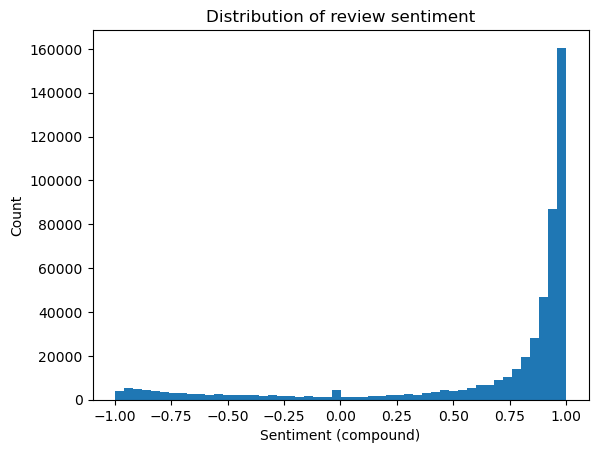

In [10]:
plt.figure()
plt.hist(df["sent_compound"], bins=50)
plt.xlabel("Sentiment (compound)")
plt.ylabel("Count")
plt.title("Distribution of review sentiment")
plt.show()


The distribution of compound sentiment scores is strongly skewed towards positive values. A large proportion of reviews cluster near the upper end of the scale (close to 1), indicating predominantly positive language. Negative sentiment scores are present but occur much less frequently and are spread more thinly across the lower end of the distribution.

This imbalance reflects a positive bias in review text, consistent with the star rating distribution, and suggests that extreme positive sentiment is more common than extreme negative sentiment in the dataset.

### Box Plot grouped by Stars

This graph is used to show the full distribution of VADER sentiment scores for each rating level, the boxplots highlight the substantial overlap and variability across stars, demonstrating that disagreement between star ratings and review text is common and systematic rather than driven by a small number of outliers.

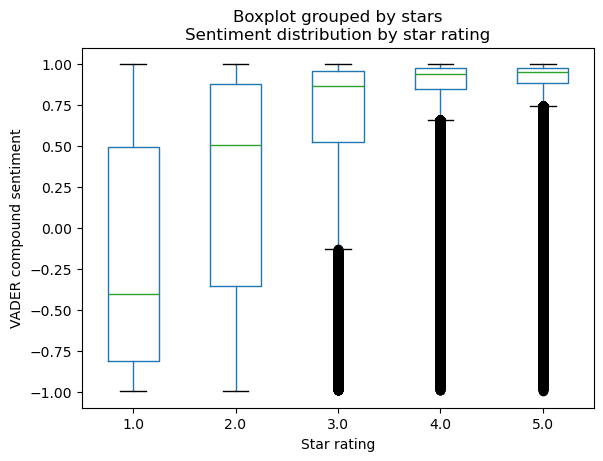

,stars
stars,1.000000
sent_compound,0.641294
n_exclaim,0.120955
caps_ratio,-0.035730
useful,-0.096807
n_words,-0.192026


In [11]:
df.boxplot(
    column="sent_compound",
    by="stars",
)

plt.xlabel("Star rating")
plt.ylabel("VADER compound sentiment")
plt.title("Sentiment distribution by star rating")
plt.grid(False)
plt.show()

# Correlation (simple summary)
corr = df[["stars", "sent_compound", "n_words", "n_exclaim", "caps_ratio", "useful"]].corr(numeric_only=True)
corr.loc[["stars"], :].T.sort_values(by="stars", ascending=False)

The boxplots show a strong positive association between star ratings and compound sentiment scores. Median sentiment increases monotonically with star rating, indicating that higher-rated reviews tend to use more positive language.

However, there is also substantial overlap between groups, particularly for mid-to-high star ratings. Notably, even 4- and 5-star reviews include a non-trivial number of reviews with neutral or negative sentiment scores, highlighting cases where textual sentiment does not fully align with the assigned star rating.

The black points indicate individual outlier reviews whose sentiment scores fall outside the typical range for a given star rating. These outliers highlight cases where the language used in a review differs substantially from what would be expected based on the assigned rating.

## 6. Defining rating - sentiment mismatch

In [12]:
# Define "mismatch": sentiment suggests positive but stars low, or sentiment negative but stars high
def mismatch_type(stars: float, sent_label: str) -> str:
    if pd.isna(stars) or pd.isna(sent_label):
        return "missing"
    if sent_label == "positive" and stars <= 2:
        return "pos_text_low_stars"
    if sent_label == "negative" and stars >= 4:
        return "neg_text_high_stars"
    return "aligned_or_mild"

df["mismatch_type"] = [mismatch_type(s, lab) for s, lab in zip(df["stars"], df["sent_label"].astype(str))]

# RQ1: how common?
df["mismatch_type"].value_counts(normalize=True).rename("proportion")

mismatch_type
aligned_or_mild        0.890000
pos_text_low_stars     0.097504
neg_text_high_stars    0.012496
Name: proportion, dtype: float64

In [13]:
# RQ2/RQ3: compare feature distributions by mismatch type
group_stats = df.groupby("mismatch_type")[["n_words", "n_exclaim", "n_question", "caps_ratio", "useful", "sent_compound", "stars"]].mean(numeric_only=True)
group_stats

,n_words,n_exclaim,n_question,caps_ratio,useful,sent_compound,stars
mismatch_type,,,,,,,
aligned_or_mild,98.203980,1.338191,0.138204,0.006310,0.977151,0.674324,4.047708
neg_text_high_stars,81.334827,1.036812,0.165813,0.008475,0.932458,-0.462348,4.545774
pos_text_low_stars,148.560510,0.899635,0.400660,0.006887,1.510235,0.682187,1.511425


### Mismatch

Three graphs are examined to analyse patterns of sentiment–rating mismatch, focusing on the frequency of mismatch, differences in review length, and variation in usefulness scores across mismatch categories.

#### Frequency of mismatch categories

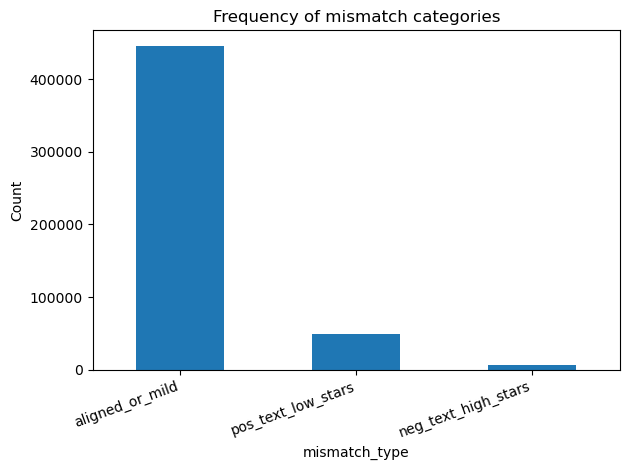

In [24]:
df["mismatch_type"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Frequency of mismatch categories")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Most reviews fall into the aligned or mildly mismatched category, indicating general agreement between star ratings and textual sentiment. Strong mismatches are relatively rare, with positive-text/low-star cases occurring more frequently than negative-text/high-star cases.

#### Text length by mismatch type



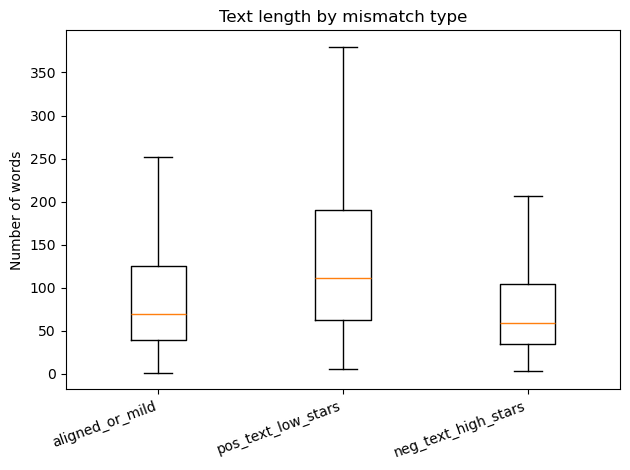

In [14]:
# Visual: boxplot of text length across mismatch categories
plt.figure()
order = ["aligned_or_mild", "pos_text_low_stars", "neg_text_high_stars"]
data = [df.loc[df["mismatch_type"] == k, "n_words"].dropna() for k in order]
plt.boxplot(data, labels=order, showfliers=False)
plt.ylabel("Number of words")
plt.title("Text length by mismatch type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Reviews with positive text but low star ratings tend to be longer on average than both aligned reviews and negative-text/high-star reviews. This suggests that strongly mismatched reviews may involve more detailed explanations, particularly when users assign low ratings despite expressing positive sentiment in the text.

#### Usefulness votes by mismatch type

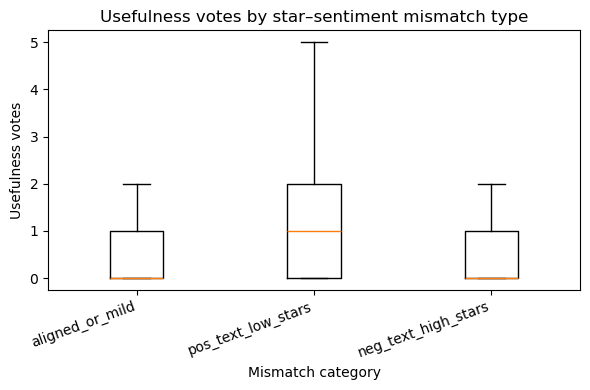

In [30]:
categories = df["mismatch_type"].unique()
data = [df.loc[df["mismatch_type"] == cat, "useful"] for cat in categories]

plt.figure(figsize=(6, 4))
plt.boxplot(data, labels=categories, showfliers=False)
plt.ylabel("Usefulness votes")
plt.xlabel("Mismatch category")
plt.title("Usefulness votes by star–sentiment mismatch type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Reviews with positive text but low star ratings receive slightly higher usefulness votes on average compared to aligned reviews and negative-text/high-star reviews. This suggests that strongly mismatched reviews, particularly those explaining low ratings despite positive language, may be perceived as more informative by other users.

## 7. Comparative analysis (effect size)

Effect sizes were used to quantify the magnitude of differences between groups, allowing the analysis to move beyond simple detection of differences to an assessment of their practical importance. By reporting effect sizes, the study evaluates whether observed patterns of sentiment–rating mismatch represent meaningful distinctions rather than small effects that arise solely due to the large sample size.


In [ ]:
strong = df["mismatch_type"].isin(["pos_text_low_stars", "neg_text_high_stars"])
x, y = df[strong], df[~strong]

def d(a, b):
    # data already cleaned
    # a = pd.to_numeric(a, errors="coerce")
    # b = pd.to_numeric(b, errors="coerce")

    # a = a.dropna().astype(float)
    # b = b.dropna().astype(float)

    if len(a) < 2 or len(b) < 2: return np.nan
    s = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return 0.0 if s == 0 else (a.mean() - b.mean()) / s

features = ["n_words", "n_question", "sent_compound"]

effect_df = (pd.DataFrame({
    "feature": features,
    "mean_strong_mismatch": [x[f].mean() for f in features],
    "mean_not_strong_mismatch":      [y[f].mean() for f in features],
    "cohens_d (strong - not)": [d(x[f], y[f]) for f in features],
}).round(3).sort_values("cohens_d (strong - not)", ascending=False))

effect_df

,feature,mean_strong_mismatch,mean_not_strong_mismatch,cohens_d (strong - not)
0,n_words,140.924,98.204,0.450
1,n_question,0.374,0.138,0.347
2,sent_compound,0.552,0.674,-0.226


The table compares mean feature values between strongly mismatched and non-strongly mismatched reviews and reports the corresponding effect sizes. Strongly mismatched reviews are notably longer and contain more question marks, both showing moderate effect sizes, indicating meaningful differences in writing length and style.

In contrast, the difference in compound sentiment scores is smaller, with a weak negative effect size. This suggests that strong mismatches are driven more by how reviews are written than by large shifts in overall sentiment intensity.

## 8. Robustness checks

Robustness checks were included to assess the stability of the findings under alternative definitions, thresholds, and modelling choices. This ensures that the main conclusions are not driven by arbitrary analytical decisions and increases confidence that the observed patterns reflect consistent structure in the data rather than methodological artefacts.

In [16]:
star_base = pd.Series(
    np.select([df["stars"] <= 2, df["stars"] >= 4],
              ["negative", "positive"],
              default="neutral"),
    index=df.index
)

star_alt = pd.Series(
    np.where(df["stars"] >= 4, "positive", "negative"),
    index=df.index
)

sent = lambda p, n: pd.Series(
    np.select([df["sent_compound"] <= n, df["sent_compound"] >= p],
              ["negative", "positive"],
              default="neutral"),
    index=df.index
)

mismatch = lambda a, b: (a.notna() & b.notna() & (a != b)).mean()

robust_df = pd.DataFrame([
    ("Baseline (stars<=2 neg, >=4 pos; sent ±0.2)", mismatch(star_base, sent(0.2, -0.2))),
    ("Alt stars (<=3 neg, >=4 pos)",               mismatch(star_alt,  sent(0.2, -0.2))),
    ("Stricter sentiment (±0.4)",                  mismatch(star_base, sent(0.4, -0.4))),
    ("Looser sentiment (±0.1)",                    mismatch(star_base, sent(0.1, -0.1))),
], columns=["setting", "mismatch_rate"]).round(3)

robust_df

,setting,mismatch_rate
0,"Baseline (stars<=2 neg, >=4 pos; sent ±0.2)",0.230
1,"Alt stars (<=3 neg, >=4 pos)",0.225
2,Stricter sentiment (±0.4),0.244
3,Looser sentiment (±0.1),0.225


## 9. Modelling exploration

The classification report was chosen to complement this by summarising performance using precision, recall, and F1-score, which are particularly appropriate for imbalanced data. Together, these measures offer a more informative assessment than overall accuracy alone, clarifying both the strengths and limitations of the classifier.

The confusion matrix and classification report were chosen to provide a clear and interpretable evaluation of how well the sentiment-based mismatch indicator distinguishes between mismatch and non-mismatch cases. The confusion matrix allows errors to be examined directly by showing the distribution of true positives, true negatives, false positives, and false negatives, making any asymmetry in misclassification immediately visible.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Simple, interpretable model: classify "strong mismatch" vs not
df["is_strong_mismatch"] = df["mismatch_type"].isin(["pos_text_low_stars", "neg_text_high_stars"]).astype(int)

features = ["sent_compound", "n_words", "n_exclaim", "n_question", "caps_ratio", "useful"]
X = df[features].fillna(0)
y = df["is_strong_mismatch"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

report = classification_report(y_test, pred, digits=3, output_dict=True)
cm = confusion_matrix(y_test, pred)

print(classification_report(y_test, pred, digits=3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0      0.933     0.717     0.811    111250
           1      0.203     0.582     0.301     13750

    accuracy                          0.702    125000
   macro avg      0.568     0.650     0.556    125000
weighted avg      0.853     0.702     0.755    125000


Confusion matrix:
 [[79774 31476]
 [ 5746  8004]]


This table and confusion matrix summarise the performance of the sentiment-based classifier under substantial class imbalance. While overall accuracy is relatively high, the results show a clear asymmetry: non-mismatch cases are identified with high precision, whereas mismatch cases exhibit lower precision but moderate recall. This indicates that the model is better at recognising non-mismatch reviews, while correctly identifying a reasonable proportion of mismatches at the cost of more false positives, highlighting both the limitations of sentiment-only classification and the inherent difficulty of detecting nuanced disagreement.


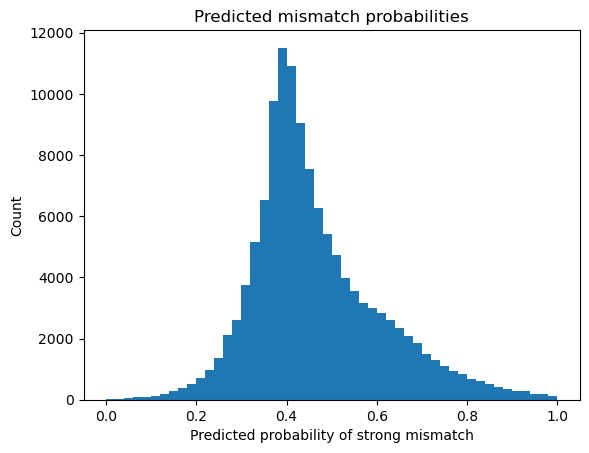

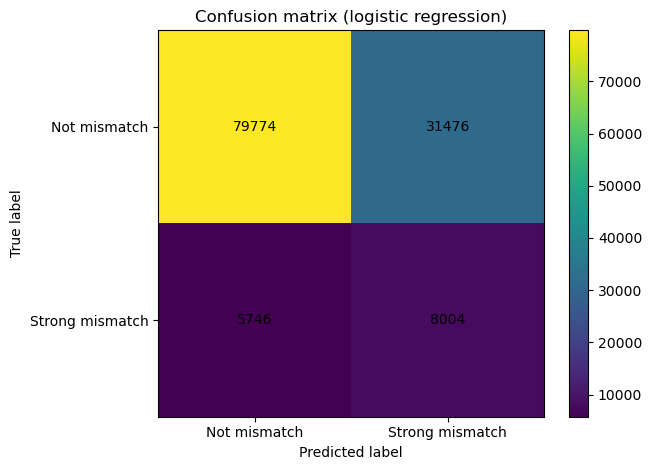

In [18]:
probs = model.predict_proba(X_test)[:, 1]

plt.figure()
plt.hist(probs, bins=50)
plt.xlabel("Predicted probability of strong mismatch")
plt.ylabel("Count")
plt.title("Predicted mismatch probabilities")
plt.show()


plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.colorbar()

plt.xticks([0, 1], ["Not mismatch", "Strong mismatch"])
plt.yticks([0, 1], ["Not mismatch", "Strong mismatch"])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix (logistic regression)")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [19]:
# Interpret coefficients (direction + magnitude)
coef = model.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": features, "coef": coef}).sort_values("coef", ascending=False)
coef_df


,feature,coef
1,n_words,0.410944
3,n_question,0.199058
5,useful,0.069613
4,caps_ratio,0.065765
0,sent_compound,-0.318516
2,n_exclaim,-0.352189


Overall, these results show that sentiment–rating mismatch is common and structured rather than random. Mismatched reviews tend to be longer, more questioning, and more detailed, and sentiment alone is not sufficient to explain disagreement with star ratings. The modelling results further indicate that non-mismatch cases are easy to identify, while mismatches are harder to classify precisely, reflecting the nuanced and ambiguous way users express mixed opinions.

## Notes / limitations

- VADER is a general-purpose lexicon; sarcasm, domain terms, and mixed reviews can confuse it.
- Star ratings can encode *non-text* factors (price, waiting time, delivery issues), so disagreement isn't necessarily an error.
- This notebook emphasises interpretability: simple features + simple models, with most effort in **analysis** rather than prediction.
